In [3]:
!pip install -q tensorflow pillow matplotlib scikit-learn seaborn
 
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import seaborn as sns
import json, time, random
 
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
IMG_SIZE     = 224
BATCH_SIZE   = 64
EPOCHS       = 10
LR           = 1e-4
LABEL_SMOOTH = 0.1
TRAIN_LIMIT  = 5000   # per class → 10000 total
VAL_LIMIT    = 1000   # per class → 2000 total
 
DATA_PATH  = '/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset'
print("Config ready.")
 

Config ready.


In [5]:
def find_folder(base, names):
    for f in os.listdir(base):
        if f.lower() in [n.lower() for n in names]:
            return os.path.join(base, f)
    return None
 
TRAIN_PATH = find_folder(DATA_PATH, ['train', 'training'])
VAL_PATH   = find_folder(DATA_PATH, ['validation', 'val', 'valid', 'test'])
 
print(f"Train: {TRAIN_PATH}")
print(f"Val:   {VAL_PATH}")
 
# Show class folders
for split, path in [("Train", TRAIN_PATH), ("Val", VAL_PATH)]:
    if path:
        for cls in sorted(os.listdir(path)):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                print(f"  {split}/{cls}: {len(os.listdir(cls_path))} images")

Train: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Train
Val:   /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation
  Train/Fake: 70001 images
  Train/Real: 70001 images
  Val/Fake: 19641 images
  Val/Real: 19787 images


In [6]:
def get_image_paths_and_labels(folder, limit_per_class=None):
    """Collect image paths and labels from class subfolders."""
    class_names = sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])
    print(f"Classes: {class_names}")
 
    all_paths, all_labels = [], []
    for label, cls in enumerate(class_names):
        cls_path = os.path.join(folder, cls)
        files = [
            os.path.join(cls_path, f)
            for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        if limit_per_class:
            files = random.sample(files, min(limit_per_class, len(files)))
        all_paths.extend(files)
        all_labels.extend([label] * len(files))
        print(f"  {cls}: {len(files)} images (label={label})")
 
    # Shuffle together
    combined = list(zip(all_paths, all_labels))
    random.shuffle(combined)
    paths, labels = zip(*combined)
    return list(paths), list(labels), class_names
 
print("Loading train paths...")
train_paths, train_labels, CLASS_NAMES = get_image_paths_and_labels(
    TRAIN_PATH, limit_per_class=TRAIN_LIMIT
)
 
print("\nLoading val paths...")
val_paths, val_labels, _ = get_image_paths_and_labels(
    VAL_PATH, limit_per_class=VAL_LIMIT
)
 
print(f"\nTotal train: {len(train_paths)}")
print(f"Total val:   {len(val_paths)}")

Loading train paths...
Classes: ['Fake', 'Real']
  Fake: 5000 images (label=0)
  Real: 5000 images (label=1)

Loading val paths...
Classes: ['Fake', 'Real']
  Fake: 1000 images (label=0)
  Real: 1000 images (label=1)

Total train: 10000
Total val:   2000


In [7]:
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)          # EfficientNet preprocessing
    return img, label
 
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    return img, label
 
AUTOTUNE = tf.data.AUTOTUNE
 
# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
    .shuffle(len(train_paths), seed=42)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
 
# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
 
steps_per_epoch = len(train_paths) // BATCH_SIZE
val_steps       = len(val_paths) // BATCH_SIZE
 
print(f"\nSteps/epoch: {steps_per_epoch}")
print(f"Val steps:   {val_steps}")

I0000 00:00:1779090600.519630      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779090600.525599      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Steps/epoch: 156
Val steps:   31


In [8]:
from collections import Counter
train_dist = Counter(train_labels)
val_dist   = Counter(val_labels)
print("Train distribution:", {CLASS_NAMES[k]: v for k, v in train_dist.items()})
print("Val distribution:",   {CLASS_NAMES[k]: v for k, v in val_dist.items()})
 

Train distribution: {'Fake': 5000, 'Real': 5000}
Val distribution: {'Real': 1000, 'Fake': 1000}


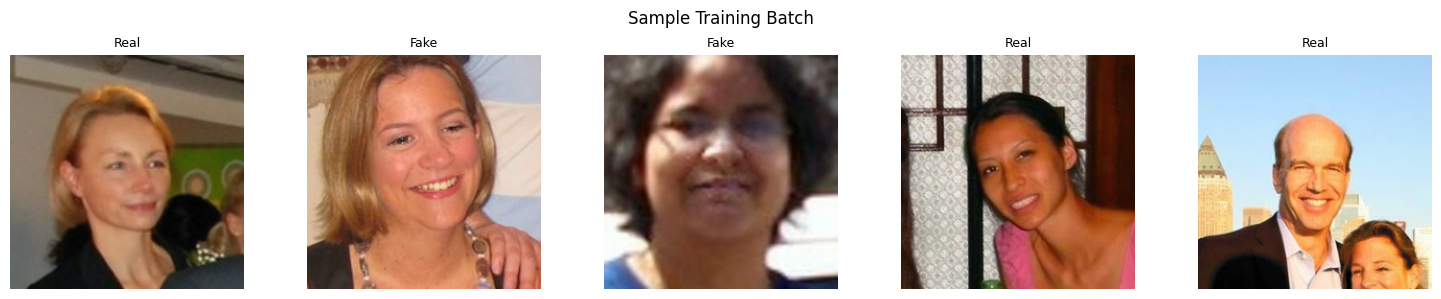

In [9]:
sample_batch = next(iter(train_ds))
imgs, lbls = sample_batch
 
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = imgs[i].numpy()
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(CLASS_NAMES[int(lbls[i])], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Training Batch")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.utils.class_weight import compute_class_weight
 
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [11]:
base = EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False
 
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
 
model = keras.Model(inputs, outputs)
 
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision', thresholds=0.5),
        keras.metrics.Recall(name='recall', thresholds=0.5),
        keras.metrics.AUC(name='auc')
    ]
)
print("Model ready.")
model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,141,280 (69.20 MB)

 Trainable params: 463,361 (1.77 MB)

 Non-trainable params: 17,677,919 (67.44 MB)

In [12]:
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
 
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        '/kaggle/working/checkpoints/best_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]
print("Callbacks ready.")

Callbacks ready.


In [13]:
print("=" * 55)
print("PHASE 1: Training head only (base frozen)")
print("=" * 55)
 
start = time.time()
history1 = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
phase1_time = time.time() - start
print(f"\nPhase 1 done in {phase1_time/60:.1f} min")

PHASE 1: Training head only (base frozen)
Epoch 1/10


I0000 00:00:1779090627.577443     171 service.cc:152] XLA service 0x7ce75c008940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779090627.577477     171 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779090627.577481     171 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779090632.362859     171 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-18 07:50:44.620660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:50:44.771764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:50:45.075274: E external/local_xl

156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5776 - auc: 0.6142 - loss: 0.8925 - precision: 0.5810 - recall: 0.5780

2026-05-18 07:51:44.420114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:51:44.553691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:51:44.784691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:51:44.923553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:51:45.172886: E external/local_xla/xla/stream_

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5778 - auc: 0.6145 - loss: 0.8921 - precision: 0.5813 - recall: 0.5783
Epoch 1: val_accuracy improved from -inf to 0.72900, saving model to /kaggle/working/checkpoints/best_phase1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 539ms/step - accuracy: 0.5781 - auc: 0.6149 - loss: 0.8917 - precision: 0.5815 - recall: 0.5785 - val_accuracy: 0.7290 - val_auc: 0.8136 - val_loss: 0.6256 - val_precision: 0.7726 - val_recall: 0.6490 - learning_rate: 1.0000e-04
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6872 - auc: 0.7523 - loss: 0.7301 - precision: 0.6887 - recall: 0.6914
Epoch 2: val_accuracy improved from 0.72900 to 0.74600, saving model to /kaggle/working/checkpoints/best_phase1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 222ms/step - accuracy: 0.6872 - auc: 0.7523 - loss: 0.7300 - precision: 0.6886 - recall: 0.6914 - val_accuracy: 0.7460 - val_auc: 0.8304 - val_loss: 0.5948 - val_precision: 0.7639 - val_recall: 0.7120 - l

In [14]:
print("\n" + "=" * 55)
print("PHASE 2: Fine-tuning top 30 layers")
print("=" * 55)
 
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
 
model.compile(
    optimizer=keras.optimizers.Adam(LR / 10),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision', thresholds=0.5),
        keras.metrics.Recall(name='recall', thresholds=0.5),
        keras.metrics.AUC(name='auc')
    ]
)
 
finetune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        '/kaggle/working/checkpoints/best_phase2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]
 
start = time.time()
history2 = model.fit(
    train_ds,
    epochs=8,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=finetune_callbacks,
    verbose=1
)
phase2_time = time.time() - start
print(f"\nPhase 2 done in {phase2_time/60:.1f} min")


PHASE 2: Fine-tuning top 30 layers
Epoch 1/8


2026-05-18 07:58:44.114196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 07:58:44.254006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6764 - auc: 0.7371 - loss: 0.7031 - precision: 0.6760 - recall: 0.6757
Epoch 1: val_accuracy improved from -inf to 0.71700, saving model to /kaggle/working/checkpoints/best_phase2.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 570ms/step - accuracy: 0.6764 - auc: 0.7372 - loss: 0.7030 - precision: 0.6760 - recall: 0.6757 - val_accuracy: 0.7170 - val_auc: 0.8120 - val_loss: 0.6153 - val_precision: 0.7512 - val_recall: 0.6490 - learning_rate: 1.0000e-05
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7003 - auc: 0.7717 - loss: 0.6697 - precision: 0.6936 - recall: 0.7016
Epoch 2: val_accuracy improved from 0.71700 to 0.71850, saving model to /kaggle/working/checkpoints/best_phase2.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 294ms/step - accuracy: 0.7003 - auc: 0.7718 - loss: 0.6697 - precision: 0.6937 - recall: 0.7016 - val_accuracy: 0.7185 - val_auc: 0.8103 - val_loss: 0.6159 - val_precision: 0.7452 - val_recall: 0.6640 - le

In [15]:
print("\nEvaluating...")
all_preds, all_labels_eval = [], []
 
for imgs, lbls in val_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(preds.flatten())
    all_labels_eval.extend(lbls.numpy())
 
pred_classes = (np.array(all_preds) > 0.5).astype(int)
true_classes = np.array(all_labels_eval)
 
acc  = accuracy_score(true_classes, pred_classes)
prec = precision_score(true_classes, pred_classes, zero_division=0)
rec  = recall_score(true_classes, pred_classes, zero_division=0)
f1   = f1_score(true_classes, pred_classes, zero_division=0)
 
print("\n" + "=" * 55)
print("FINAL RESULTS")
print("=" * 55)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print("=" * 55)
print(classification_report(true_classes, pred_classes,
      target_names=CLASS_NAMES))


Evaluating...


2026-05-18 08:06:00.534446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 08:06:00.672546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 08:06:00.925017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 08:06:01.068620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 08:06:01.382540: E external/local_xla/xla/stream_


FINAL RESULTS
Accuracy:  76.50%
Precision: 77.43%
Recall:    74.80%
F1-Score:  76.09%
              precision    recall  f1-score   support

        Fake       0.76      0.78      0.77      1000
        Real       0.77      0.75      0.76      1000

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.76      2000
weighted avg       0.77      0.77      0.76      2000



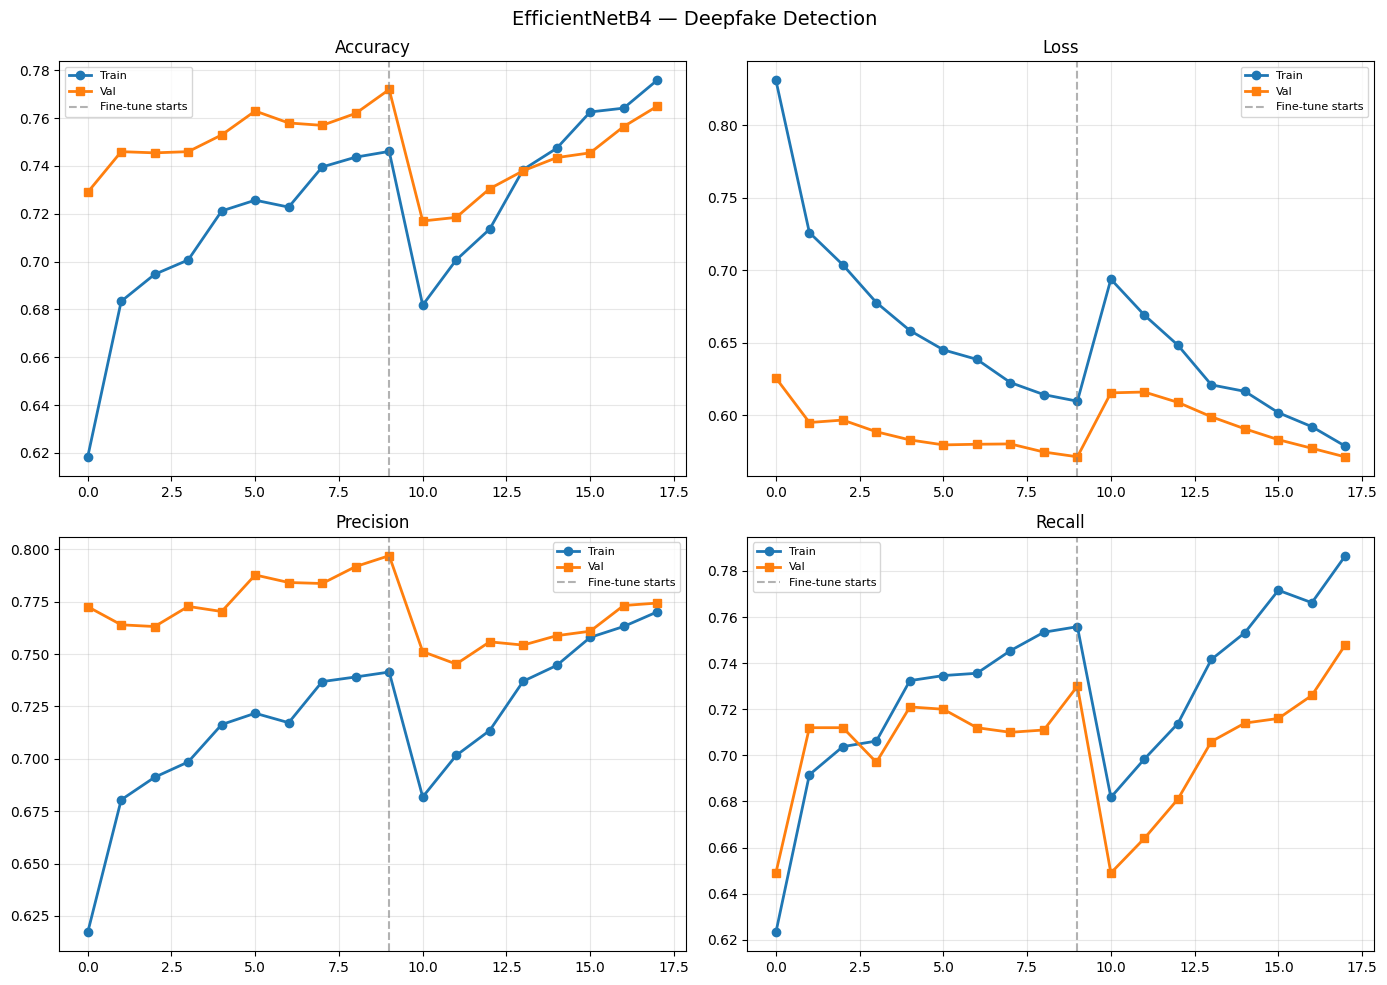

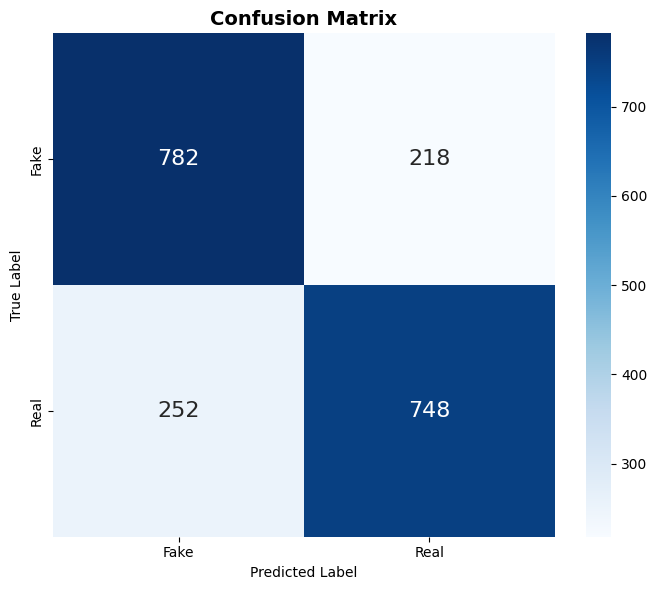

In [16]:
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    return combined
 
hist   = combine_histories(history1, history2)
p1_end = len(history1.history['accuracy'])
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EfficientNetB4 — Deepfake Detection', fontsize=14)
 
for ax, metric, title in [
    (axes[0,0], 'accuracy',  'Accuracy'),
    (axes[0,1], 'loss',      'Loss'),
    (axes[1,0], 'precision', 'Precision'),
    (axes[1,1], 'recall',    'Recall'),
]:
    ax.plot(hist[metric],          'o-', label='Train', lw=2)
    ax.plot(hist[f'val_{metric}'], 's-', label='Val',   lw=2)
    ax.axvline(p1_end - 1, color='gray', linestyle='--',
               alpha=0.6, label='Fine-tune starts')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
model.save('/kaggle/working/deepfake_efficientnet_final.keras')
 
serializable = {k: [float(v) for v in vals] for k, vals in hist.items()}
with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump(serializable, f)
 
print("\n" + "=" * 55)
print("FILES SAVED TO /kaggle/working/")
print("  - deepfake_efficientnet_final.keras")
print("  - checkpoints/best_phase1.keras")
print("  - checkpoints/best_phase2.keras")
print("  - training_curves.png")
print("  - confusion_matrix.png")
print("  - training_history.json")
print("=" * 55)
print("\nStep 1 DONE. Next → Step 2: Frequency Domain Branch")


FILES SAVED TO /kaggle/working/
  - deepfake_efficientnet_final.keras
  - checkpoints/best_phase1.keras
  - checkpoints/best_phase2.keras
  - training_curves.png
  - confusion_matrix.png
  - training_history.json

Step 1 DONE. Next → Step 2: Frequency Domain Branch
